In [1]:
import os
os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '1'
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

In [2]:
!pip install timm --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os

import timm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
data_dir = "/kaggle/input/datasets/veeraiahkondra/venkat-kondra/Final_Data"  # change this



In [5]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

In [6]:
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']


In [7]:
labels = train_dataset.targets
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [8]:
model = timm.create_model('vit_small_patch16_224', pretrained=True)

# Replace classifier head
num_features = model.head.in_features
model.head = nn.Linear(num_features, len(class_names))

model = model.to(device)

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

In [9]:
for param in model.parameters():
    param.requires_grad = False

for param in model.head.parameters():
    param.requires_grad = True

In [10]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=2, factor=0.3
)

In [11]:
def train_model(model, train_loader, val_loader, epochs=30):
    best_f1 = 0.0
    scaler = torch.cuda.amp.GradScaler()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        val_preds = []
        val_labels = []
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss = val_loss / len(val_loader.dataset)
        val_acc = (np.array(val_preds) == np.array(val_labels)).mean()
        val_f1 = f1_score(val_labels, val_preds, average='macro')

        scheduler.step(val_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_model_vit.pth")

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")
        print(f"Best F1: {best_f1:.4f}")
        print("-"*50)

    model.load_state_dict(torch.load("best_model_vit.pth"))
    return model

In [12]:
model = train_model(model, train_loader, val_loader, epochs=10)

/tmp/ipykernel_55/983819229.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_55/983819229.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/10
Train Loss: 0.8701 | Train Acc: 0.6528
Val Loss: 0.7764 | Val Acc: 0.6782 | Val F1: 0.6377
Best F1: 0.6377
--------------------------------------------------


/tmp/ipykernel_55/983819229.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2/10
Train Loss: 0.5875 | Train Acc: 0.7737
Val Loss: 0.6456 | Val Acc: 0.7432 | Val F1: 0.7295
Best F1: 0.7295
--------------------------------------------------


/tmp/ipykernel_55/983819229.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 8/10
Train Loss: 0.4539 | Train Acc: 0.8158
Val Loss: 0.4974 | Val Acc: 0.7927 | Val F1: 0.7900
Best F1: 0.7960
--------------------------------------------------


/tmp/ipykernel_55/983819229.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 9/10
Train Loss: 0.4409 | Train Acc: 0.8227
Val Loss: 0.4650 | Val Acc: 0.8094 | Val F1: 0.8076
Best F1: 0.8076
--------------------------------------------------


/tmp/ipykernel_55/983819229.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 10/10
Train Loss: 0.4384 | Train Acc: 0.8233
Val Loss: 0.4682 | Val Acc: 0.8051 | Val F1: 0.8050
Best F1: 0.8076
--------------------------------------------------


In [13]:
for param in model.blocks[-2:].parameters():
    param.requires_grad = True

In [14]:
model = train_model(model, train_loader, val_loader, epochs=20)

/tmp/ipykernel_55/983819229.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_55/983819229.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/20
Train Loss: 0.6237 | Train Acc: 0.7768
Val Loss: 0.4945 | Val Acc: 0.7964 | Val F1: 0.7884
Best F1: 0.7884
--------------------------------------------------


/tmp/ipykernel_55/983819229.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2/20
Train Loss: 0.4490 | Train Acc: 0.8121
Val Loss: 0.4095 | Val Acc: 0.8274 | Val F1: 0.8242
Best F1: 0.8242
--------------------------------------------------


/tmp/ipykernel_55/983819229.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 15/20
Train Loss: 0.2319 | Train Acc: 0.9014
Val Loss: 0.3237 | Val Acc: 0.8700 | Val F1: 0.8698
Best F1: 0.8698
--------------------------------------------------


/tmp/ipykernel_55/983819229.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 19/20
Train Loss: 0.2109 | Train Acc: 0.9151
Val Loss: 0.3066 | Val Acc: 0.8756 | Val F1: 0.8742
Best F1: 0.8742
--------------------------------------------------


/tmp/ipykernel_55/983819229.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 20/20
Train Loss: 0.2075 | Train Acc: 0.9144
Val Loss: 0.3388 | Val Acc: 0.8707 | Val F1: 0.8681
Best F1: 0.8742
--------------------------------------------------


In [15]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

                     precision    recall  f1-score   support

           Covid-19       0.99      0.99      0.99       405
             Normal       0.95      0.94      0.94       405
Pneumonia-Bacterial       0.75      0.83      0.79       405
    Pneumonia-Viral       0.80      0.71      0.75       405

           accuracy                           0.87      1620
          macro avg       0.87      0.87      0.87      1620
       weighted avg       0.87      0.87      0.87      1620



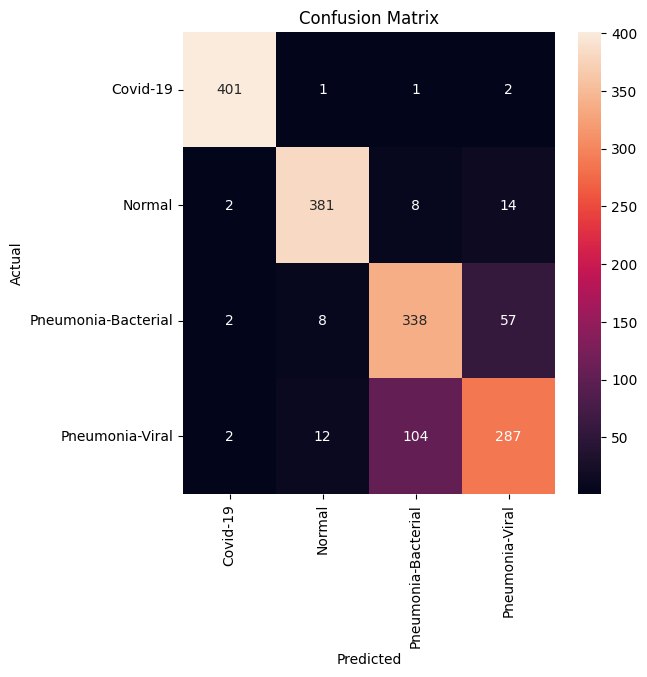

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [18]:
model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [19]:
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

In [20]:
all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

print(all_probs.shape)   # (N, num_classes)
print(all_labels.shape)  # (N,)

(1620, 4)
(1620,)


In [21]:
num_classes = all_probs.shape[1]

all_labels_bin = label_binarize(
    all_labels,
    classes=list(range(num_classes))
)

In [22]:
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

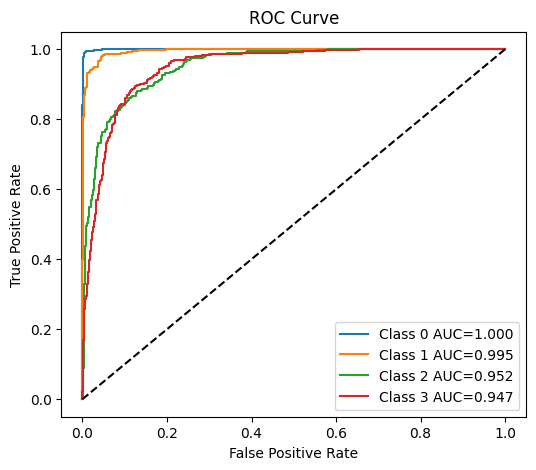

In [23]:
plt.figure(figsize=(6,5))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} AUC={roc_auc[i]:.3f}")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [24]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, x, class_idx):
        output = self.model(x)
        self.model.zero_grad()

        loss = output[0, class_idx]
        loss.backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = gradients.mean(dim=(1,2))

        cam = torch.zeros(activations.shape[1:], device=x.device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)
        cam -= cam.min()
        cam /= cam.max()

        return cam.detach().cpu().numpy()

In [ ]:
images, labels = next(iter(test_loader))

img = images[0:1].to(device)
label = labels[0].item()

cam = grad_cam.generate(img, label)

In [ ]:
import cv2

img_np = img.squeeze().permute(1,2,0).cpu().numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

heatmap = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

overlay = heatmap * 0.4 + img_np * 255

plt.imshow(overlay.astype(np.uint8))
plt.axis('off')
plt.title("Grad-CAM")
plt.show()

In [26]:
def vit_attention_map(model, img):
    model.eval()

    with torch.no_grad():
        features = model.forward_features(img)  # shape: (1, tokens, dim)

    # Remove CLS token
    attn = features[:, 1:, :]

    # Average embedding channels
    attn = attn.mean(dim=2)

    # Convert to square map
    size = int(attn.shape[1] ** 0.5)
    attn = attn.reshape(size, size)

    attn = attn.cpu().numpy()
    attn = (attn - attn.min()) / (attn.max() - attn.min())

    return attn

In [28]:
images, labels = next(iter(test_loader))

img = images[0:1].to(device)

attn_map = vit_attention_map(model, img)

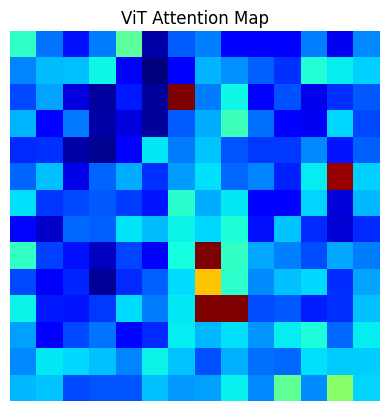

In [29]:
attn_map = vit_attention_map(model, img)

plt.imshow(attn_map, cmap='jet')
plt.title("ViT Attention Map")
plt.axis('off')
plt.show()

In [30]:
import cv2

In [31]:
class RISE:
    def __init__(self, model, input_size, device):
        self.model = model
        self.input_size = input_size
        self.device = device

    def generate_masks(self, N=500, s=8, p1=0.5):
        masks = []
        for _ in range(N):
            mask = (np.random.rand(s, s) < p1).astype(np.float32)
            mask = cv2.resize(mask, self.input_size)
            masks.append(mask)
        return np.array(masks)

    def explain(self, image, masks):
        preds = []

        for mask in masks:
            mask_tensor = torch.tensor(mask).to(self.device)
            masked_img = image * mask_tensor
            masked_img = masked_img.unsqueeze(0)

            with torch.no_grad():
                pred = torch.softmax(self.model(masked_img), dim=1)

            preds.append(pred.cpu().numpy())

        preds = np.concatenate(preds)

        saliency = np.zeros(self.input_size)

        for i in range(len(masks)):
            saliency += preds[i].max() * masks[i]

        saliency /= len(masks)

        return saliency

In [32]:
rise = RISE(model, (224,224), device)

In [33]:
masks = rise.generate_masks(N=500, s=8, p1=0.5)

In [34]:
images, labels = next(iter(test_loader))
img = images[0].to(device)

saliency = rise.explain(img, masks)

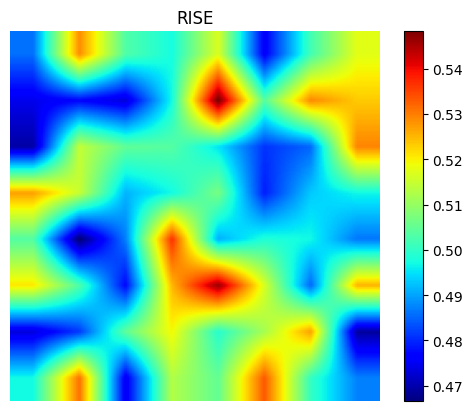

In [35]:
plt.imshow(saliency, cmap='jet')
plt.colorbar()
plt.title("RISE")
plt.axis('off')
plt.show()